In [1]:
"""
CLASIFICACIÓN DE ESTILOS TÁCTICOS - FC BARCELONA
Análisis de Patrones de Juego mediante Machine Learning
"""

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.models.classical_ml import TacticalStyleClassifier

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Librerías cargadas")
print("CLASIFICACIÓN DE ESTILOS TÁCTICOS")
print("   FC Barcelona - Temporada 2020/21")


Librerías cargadas
CLASIFICACIÓN DE ESTILOS TÁCTICOS
   FC Barcelona - Temporada 2020/21


In [2]:
# CARGA DEL DATASET

import os

# Verificoms si el archivo existe
file_path = '../data/processed/barcelona_ml_dataset.csv'

if not os.path.exists(file_path):
    print(" Archivo no encontrado en:", file_path)
    print("\n Buscando archivos en data/processed/:")
    
    
    processed_dir = '../data/processed/'
    if os.path.exists(processed_dir):
        files = os.listdir(processed_dir)
        print(f"   Archivos encontrados: {files}")
        
       
        csv_files = [f for f in files if f.endswith('.csv')]
        
        if csv_files:
            print(f"\n Archivos CSV disponibles:")
            for f in csv_files:
                print(f"   - {f}")
            
            # Si hay un archivo con 'barcelona' o 'balanced', usarlo
            for f in csv_files:
                if 'barcelona' in f.lower():
                    file_path = os.path.join(processed_dir, f)
                    print(f"\n Usando: {f}")
                    break
                elif 'balanced' in f.lower():
                    file_path = os.path.join(processed_dir, f)
                    print(f"\n Usando: {f}")
                    break
        else:
            print("\n No hay archivos CSV en data/processed/")
            
            raise FileNotFoundError("Dataset no encontrado")
    else:
        print("Carpeta data/processed/ no existe")
        raise FileNotFoundError("Carpeta data/processed/ no encontrada")

# Cargar dataset
df = pd.read_csv(file_path)

print(f"\n Dataset cargado desde: {file_path}")
print(f"   - Shape: {df.shape}")
print(f"   - Instancias totales: {len(df)}")

# Separamos Barcelona y rivales
if 'es_barcelona' in df.columns:
    df_barcelona = df[df['es_barcelona'] == True].copy()
    df_rivales = df[df['es_barcelona'] == False].copy()
    
    print(f"\n Distribución:")
    print(f"   - Instancias Barcelona: {len(df_barcelona)}")
    print(f"   - Instancias rivales: {len(df_rivales)}")
else:
    print("\n Columna 'es_barcelona' no encontrada")
    print("   Analizando todas las instancias como Barcelona")
    df_barcelona = df[df['team'] == 'Barcelona'].copy()
    df_rivales = df[df['team'] != 'Barcelona'].copy()
    
    print(f"\n Distribución:")
    print(f"   - Instancias Barcelona: {len(df_barcelona)}")
    print(f"   - Otras instancias: {len(df_rivales)}")

print(f"\n Columnas disponibles: {df.shape[1]}")
print(f"\n Primeras filas:")
display(df.head())


 Dataset cargado desde: ../data/processed/barcelona_ml_dataset.csv
   - Shape: (204, 73)
   - Instancias totales: 204

 Distribución:
   - Instancias Barcelona: 102
   - Instancias rivales: 102

 Columnas disponibles: 73

 Primeras filas:


,match_id,team,total_passes,unique_players,unique_recipients,successful_passes,pass_accuracy,avg_pass_distance,max_pass_distance,min_pass_distance,std_pass_distance,total_pass_distance,passes_first_half,passes_second_half,passes_ratio_halves,avg_passes_per_player,max_passes_per_player,std_passes_per_player,static_num_nodes,static_num_edges,static_density,static_avg_degree,static_max_degree,static_min_degree,static_std_degree,static_avg_in_degree,static_max_in_degree,static_avg_out_degree,static_max_out_degree,static_avg_clustering,static_max_clustering,static_std_clustering,static_avg_betweenness,static_max_betweenness,static_std_betweenness,static_avg_pagerank,static_max_pagerank,static_std_pagerank,static_avg_closeness,static_max_closeness,static_is_connected,static_num_components,static_avg_edge_weight,static_max_edge_weight,static_std_edge_weight,static_total_edge_weight,temporal_density_mean,temporal_density_std,temporal_density_max,temporal_density_min,temporal_density_range,temporal_density_variability,temporal_clustering_mean,temporal_clustering_std,temporal_edges_mean,temporal_edges_std,temporal_edges_max,temporal_density_first_half,temporal_density_second_half,temporal_density_change_halves,temporal_clustering_first_half,temporal_clustering_second_half,temporal_density_trend,resultado,goles_equipo,goles_rival,xg_equipo,xg_rival,xg_diff,contexto,rival,tipo_rival,es_barcelona
0,3773386,Barcelona,850,16,16,784,0.922353,15.739749,51.685588,1.581139,8.327888,13378.786953,379,471,1.242744,53.125,104,31.185199,16,152,0.633333,19.000,28,3,6.442049,9.5000,14,9.5000,14,0.174252,0.242308,0.037640,0.087222,0.267619,0.070609,0.0625,0.108914,0.028374,0.317958,0.405405,1,1,5.592105,22,4.575903,850,0.309218,0.065833,0.433333,0.154545,0.278788,0.051903,0.220617,0.073190,30.666667,8.538607,48,0.279748,0.334154,0.054407,0.216661,0.223963,0.000928,empate,1,1,2.091130,1.128524,0.962606,visitante,Deportivo Alavés,medio,True
1,3773386,Deportivo Alavés,210,16,15,154,0.733333,24.261890,88.395588,1.500000,19.889043,5094.996963,118,92,0.779661,13.125,22,6.771263,16,98,0.408333,12.250,20,1,4.930771,6.1250,11,6.1250,12,0.184572,0.312435,0.076889,0.065866,0.290134,0.071301,0.0625,0.119166,0.034234,0.410908,0.576923,1,1,2.142857,7,1.392399,210,0.180997,0.060516,0.333333,0.090909,0.242424,0.052010,0.135166,0.146499,10.279070,5.754193,27,0.160386,0.197314,0.036928,0.101617,0.161725,0.000519,empate,1,1,1.128524,2.091130,-0.962606,local,Barcelona,medio,False
2,3773565,Barcelona,826,16,16,765,0.926150,17.889546,67.556347,1.979899,10.106293,14776.765379,339,487,1.436578,51.625,121,30.711290,16,156,0.650000,19.500,30,11,5.700877,9.7500,15,9.7500,15,0.161146,0.246428,0.051728,0.074369,0.164819,0.053859,0.0625,0.122282,0.028256,0.360671,0.483871,1,1,5.294872,23,4.715248,826,0.307835,0.087258,0.522222,0.160714,0.361508,0.065295,0.246170,0.061889,31.913043,11.014790,54,0.270132,0.342397,0.072265,0.217807,0.272170,0.000670,victoria,4,0,1.492826,0.450980,1.041847,visitante,Granada,medio,True
3,3773565,Granada,316,16,16,255,0.806962,22.718700,88.319024,1.897367,16.331183,7179.109139,191,125,0.654450,19.750,38,10.560934,16,128,0.533333,16.000,23,6,4.847680,8.0000,12,8.0000,13,0.205579,0.281667,0.039000,0.064320,0.231468,0.059414,0.0625,0.102112,0.021165,0.439853,0.555556,1,1,2.468750,16,1.849567,316,0.192501,0.057704,0.392857,0.100000,0.292857,0.045236,0.176824,0.134881,15.272727,6.872133,30,0.195190,0.190046,-0.005144,0.143242,0.207485,-0.000237,derrota,0,4,0.450980,1.492826,-1.041847,local,Barcelona,medio,False
4,3773457,Barcelona,740,16,16,688,0.929730,19.365560,71.758623,1.788854,10.990074,14330.514190,416,324,0.778846,46.250,93,28.746014,16,161,0.670833,20.125,29,7,5.872340,10.0625,15,10.0625,15,0.131531,0.201304,0.035159,0.067741,0.131474,0.030552,0.0625,0.117363,0.031799,0.442366,0.535714,1,1,4.596273,27,4.936087,740,0.296520,0.060646,0.455556,0.189394,0.266162,0.051766,0.220384,0.077894,29.391304,7.237183,46,0.322124,0.273050,-0.049073,0.240209,0.202211,

In [3]:
# DEFINICIÓN DE ESTILOS TÁCTICOS

print("\n DEFINIENDO ESTILOS TÁCTICOS\n")
print("Basado en análisis de métricas de grafos y patrones de pases")


# Ver estadísticas de las columnas clave
print("\n Estadísticas de métricas clave:")
key_metrics = ['static_density', 'total_passes', 'pass_accuracy', 'static_avg_clustering']
print(df[key_metrics].describe())

def classify_tactical_style(row):
    """
    Clasifica estilo táctico basado en métricas de red y pases.
    
    ESTILOS:
    - 'posesion_alta': Control total, muchos pases, alta densidad
    - 'posesion_moderada': Posesión pero más vertical
    - 'equilibrado': Balance entre posesión y verticalidad
    - 'directo': Menos pases, menos densidad, más vertical
    """
    
    density = row['static_density']
    passes = row['total_passes']
    pass_acc = row['pass_accuracy']
    
    # Reglas de clasificación basadas en las estadísticas
    # densidad media: 0.61, pases media: 560
    
    if density > 0.65 and passes > 600 and pass_acc > 0.87:
        return 'posesion_alta'
    elif density > 0.58 and passes > 450:
        return 'posesion_moderada'
    elif density < 0.50 or passes < 350:
        return 'directo'
    else:
        return 'equilibrado'

# Aplicar clasificación a df completo
print("\n Aplicando clasificación de estilos...")
df['estilo_tactico'] = df.apply(classify_tactical_style, axis=1)

print("\n Distribución de estilos (clasificación inicial):")
style_counts = df['estilo_tactico'].value_counts()
print(style_counts)

print("\n Actualizando dataframes de Barcelona y rivales...")

df_barcelona = df[df['es_barcelona'] == True].copy()
df_rivales = df[df['es_barcelona'] == False].copy()

print(f"   - Instancias Barcelona actualizadas: {len(df_barcelona)}")
print(f"   - Instancias rivales actualizadas: {len(df_rivales)}")

print("\n Estilos de Barcelona:")
barca_styles = df_barcelona['estilo_tactico'].value_counts()
print(barca_styles)

print("\n Estilos de rivales:")
rival_styles = df_rivales['estilo_tactico'].value_counts()
print(rival_styles)

# Verificamos que todas las clases tienen al menos 2 muestras
min_samples = style_counts.min()
print(f"\n Estadísticas de clases:")
print(f"   - Mínimo de muestras por clase: {min_samples}")
print(f"   - Máximo de muestras por clase: {style_counts.max()}")
print(f"   - Total de clases: {len(style_counts)}")

if min_samples < 2:
    print("\n  Alguna clase tiene muy pocas muestras")
    print("   Aplicaremos reclasificación con percentiles en la siguiente celda")
else:
    print("\nTodas las clases tienen suficientes muestras para ML")


 DEFINIENDO ESTILOS TÁCTICOS

Basado en análisis de métricas de grafos y patrones de pases

 Estadísticas de métricas clave:
       static_density  total_passes  pass_accuracy  static_avg_clustering
count      204.000000    204.000000     204.000000             204.000000
mean         0.639952    541.357843       0.865476               0.169205
std          0.084947    205.574946       0.066272               0.038888
min          0.325000    180.000000       0.635965               0.090537
25%          0.587809    365.750000       0.833733               0.139590
50%          0.651190    543.000000       0.883466               0.166694
75%          0.703297    720.250000       0.911763               0.197098
max          0.801282   1019.000000       0.987952               0.281859

 Aplicando clasificación de estilos...

 Distribución de estilos (clasificación inicial):
estilo_tactico
posesion_alta        66
posesion_moderada    52
directo              44
equilibrado          42
Name: 

In [4]:
# ANÁLISIS Y RECLASIFICACIÓN CON PERCENTILES

print("\n ANÁLISIS DE MÉTRICAS POR PERCENTILES\n")

# Métricas clave para clasificación
key_metrics = ['static_density', 'total_passes', 'pass_accuracy', 
               'static_avg_clustering', 'static_avg_betweenness']

# Calculamos percentiles
percentiles_33 = df[key_metrics].quantile(0.33)
percentiles_66 = df[key_metrics].quantile(0.66)

print(" Percentiles para clasificación:")
print("\nPercentil 33%:")
for col in key_metrics:
    print(f"   {col:30s}: {percentiles_33[col]:.4f}")

print("\nPercentil 66%:")
for col in key_metrics:
    print(f"   {col:30s}: {percentiles_66[col]:.4f}")

# Reclasificación basada en percentiles
def classify_style_percentiles(row):
    """
    Clasificación más robusta usando percentiles del dataset.
    """
    density = row['static_density']
    passes = row['total_passes']
    pass_acc = row['pass_accuracy']
    
    # Score de posesión (de 0 a3)
    possession_score = 0
    
    if density > percentiles_66['static_density']:
        possession_score += 1
    if passes > percentiles_66['total_passes']:
        possession_score += 1
    if pass_acc > percentiles_66['pass_accuracy']:
        possession_score += 1
    
    # Score directo (0-3)
    direct_score = 0
    if density < percentiles_33['static_density']:
        direct_score += 1
    if passes < percentiles_33['total_passes']:
        direct_score += 1
    if pass_acc < percentiles_33['pass_accuracy']:
        direct_score += 1

    
    # Clasificación final
    if possession_score >= 2:
        return 'posesion_alta'
    elif direct_score >= 2:
        return 'directo'
    elif possession_score == 1 and direct_score == 0:
        return 'posesion_moderada'
    else:
        return 'equilibrado'

# Aplicamos la clasificación nueva
df['estilo_tactico'] = df.apply(classify_style_percentiles, axis=1)

print("\n Distribución FINAL de estilos:")
style_counts = df['estilo_tactico'].value_counts()
print(style_counts)

print("\n Barcelona específicamente:")
df_barcelona['estilo_tactico'] = df_barcelona.apply(classify_style_percentiles, axis=1)
barca_styles = df_barcelona['estilo_tactico'].value_counts()
print(barca_styles)

print("\n Rivales:")
df_rivales['estilo_tactico'] = df_rivales.apply(classify_style_percentiles, axis=1)
rival_styles = df_rivales['estilo_tactico'].value_counts()
print(rival_styles)

# Verificar que hay suficientes instancias por clase
min_samples = style_counts.min()
print(f"\n Mínimo de muestras por clase: {min_samples}")

if min_samples < 2:
    print("\n Alguna clase tiene muy pocas muestras")
    
    # Fusionar posesion_alta y posesion_moderada
    print("\n Fusionando 'posesion_alta' y 'posesion_moderada' en 'posesion'")
    
    df['estilo_tactico'] = df['estilo_tactico'].replace({
        'posesion_alta': 'posesion',
        'posesion_moderada': 'posesion'
    })
    
    df_barcelona['estilo_tactico'] = df_barcelona['estilo_tactico'].replace({
        'posesion_alta': 'posesion',
        'posesion_moderada': 'posesion'
    })
    
    df_rivales['estilo_tactico'] = df_rivales['estilo_tactico'].replace({
        'posesion_alta': 'posesion',
        'posesion_moderada': 'posesion'
    })
    
    print("\n Distribución FINAL (después de fusión):")
    print(df['estilo_tactico'].value_counts())
    
    print("\n Barcelona:")
    print(df_barcelona['estilo_tactico'].value_counts())
    
    print("\n Rivales:")
    print(df_rivales['estilo_tactico'].value_counts())

print("\n Clasificación de estilos completada")


 ANÁLISIS DE MÉTRICAS POR PERCENTILES

 Percentiles para clasificación:

Percentil 33%:
   static_density                : 0.6167
   total_passes                  : 412.9900
   pass_accuracy                 : 0.8512
   static_avg_clustering         : 0.1492
   static_avg_betweenness        : 0.0704

Percentil 66%:
   static_density                : 0.6813
   total_passes                  : 659.9400
   pass_accuracy                 : 0.9031
   static_avg_clustering         : 0.1832
   static_avg_betweenness        : 0.0801

 Distribución FINAL de estilos:
estilo_tactico
posesion_alta        72
directo              65
equilibrado          46
posesion_moderada    21
Name: count, dtype: int64

 Barcelona específicamente:
estilo_tactico
posesion_alta        71
equilibrado          16
posesion_moderada    15
Name: count, dtype: int64

 Rivales:
estilo_tactico
directo              65
equilibrado          30
posesion_moderada     6
posesion_alta         1
Name: count, dtype: int64

 Mínimo de

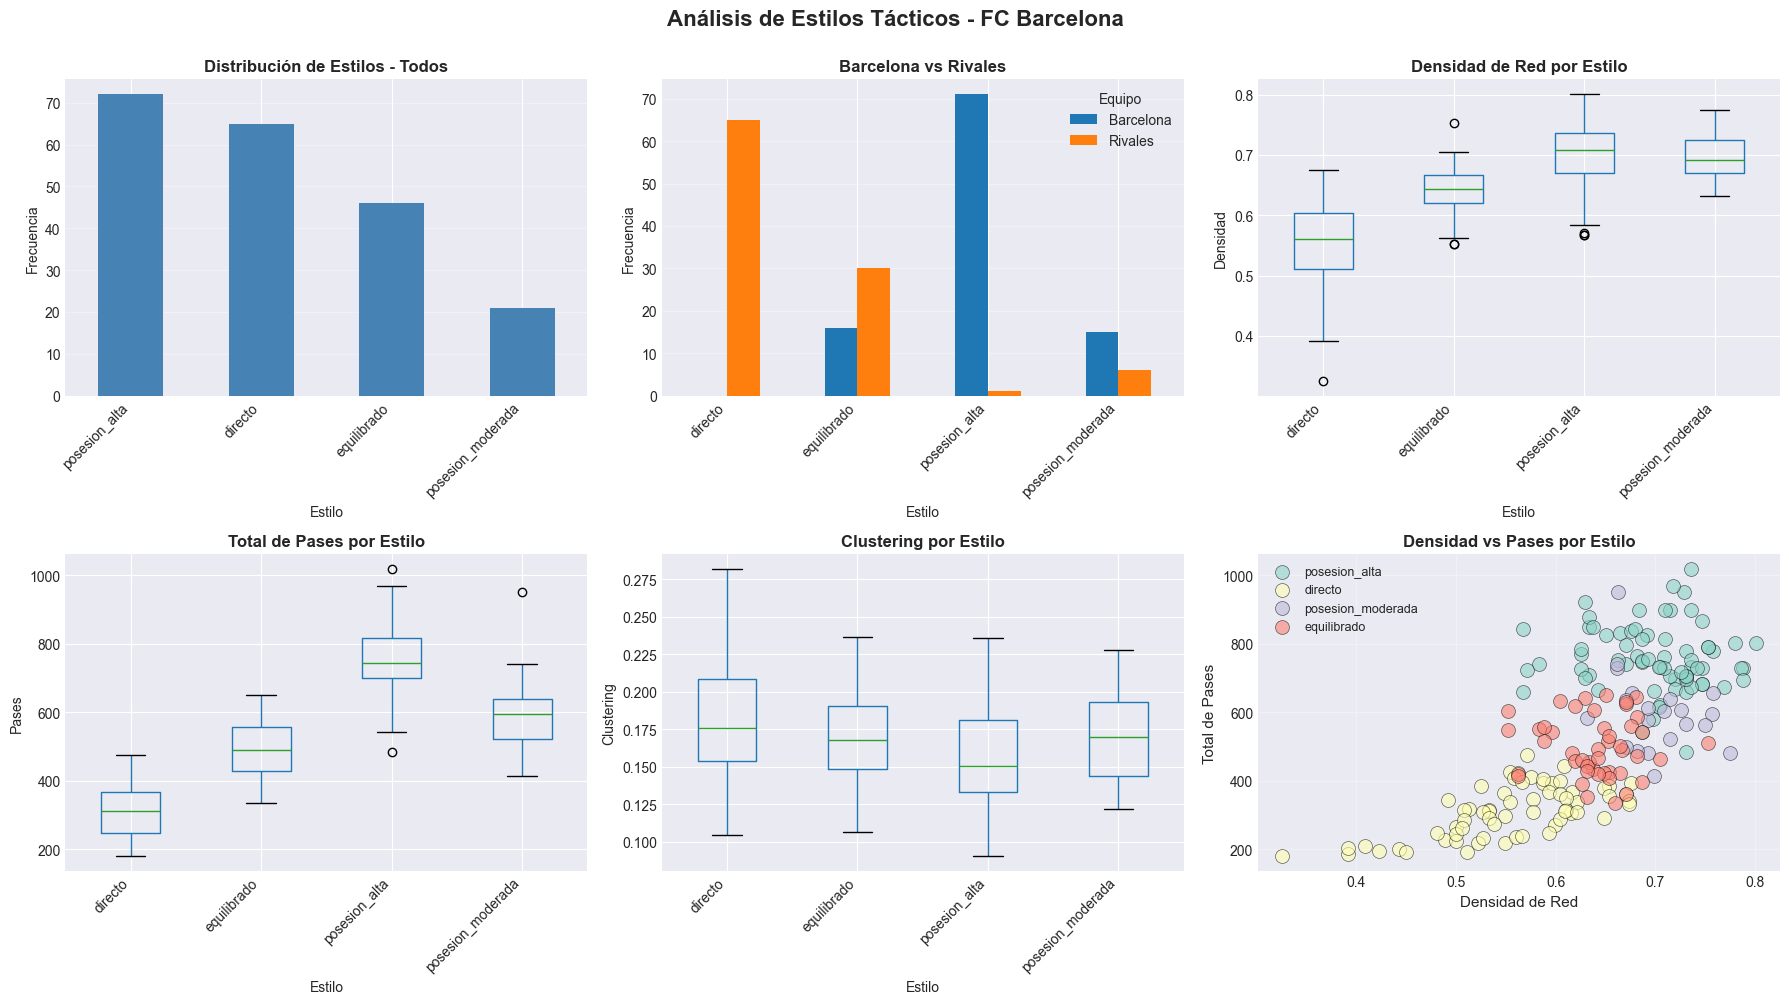

In [5]:
# VISUALIZACIÓN DE ESTILOS TÁCTICOS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución general
style_counts = df['estilo_tactico'].value_counts()
style_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribución de Estilos - Todos', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Estilo')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Barcelona vs Rivales
comparison = pd.DataFrame({
    'Barcelona': df_barcelona['estilo_tactico'].value_counts(),
    'Rivales': df_rivales['estilo_tactico'].value_counts()
}).fillna(0)

comparison.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Barcelona vs Rivales', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Estilo')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend(title='Equipo')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Densidad por estilo
df.boxplot(column='static_density', by='estilo_tactico', ax=axes[0, 2])
axes[0, 2].set_title('Densidad de Red por Estilo', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('Estilo')
axes[0, 2].set_ylabel('Densidad')
axes[0, 2].get_figure().suptitle('')  # Quitar título automático
plt.sca(axes[0, 2])
plt.xticks(rotation=45, ha='right')

# 4. Pases por estilo
df.boxplot(column='total_passes', by='estilo_tactico', ax=axes[1, 0])
axes[1, 0].set_title('Total de Pases por Estilo', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Estilo')
axes[1, 0].set_ylabel('Pases')
axes[1, 0].get_figure().suptitle('')
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# 5. Clustering por estilo
df.boxplot(column='static_avg_clustering', by='estilo_tactico', ax=axes[1, 1])
axes[1, 1].set_title('Clustering por Estilo', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Estilo')
axes[1, 1].set_ylabel('Clustering')
axes[1, 1].get_figure().suptitle('')
plt.sca(axes[1, 1])
plt.xticks(rotation=45, ha='right')

# 6. Densidad vs Pases 
styles_unique = df['estilo_tactico'].unique()
colors = plt.cm.Set3(range(len(styles_unique)))

for style, color in zip(styles_unique, colors):
    style_data = df[df['estilo_tactico'] == style]
    axes[1, 2].scatter(style_data['static_density'], style_data['total_passes'],
                      label=style, alpha=0.6, s=100, color=color, edgecolors='black', linewidth=0.5)

axes[1, 2].set_xlabel('Densidad de Red', fontsize=11)
axes[1, 2].set_ylabel('Total de Pases', fontsize=11)
axes[1, 2].set_title('Densidad vs Pases por Estilo', fontweight='bold', fontsize=12)
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(alpha=0.3)

plt.suptitle('Análisis de Estilos Tácticos - FC Barcelona', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


 CARACTERÍSTICAS PROMEDIO POR ESTILO TÁCTICO

Promedios por estilo:


,total_passes,pass_accuracy,static_density,static_avg_clustering,static_avg_betweenness,static_avg_degree,temporal_density_mean
estilo_tactico,,,,,,,
directo,311.400,0.800,0.554,0.182,0.071,15.198,0.198
equilibrado,499.870,0.866,0.640,0.168,0.076,17.307,0.230
posesion_alta,758.361,0.917,0.700,0.157,0.081,18.757,0.287
posesion_moderada,600.000,0.893,0.701,0.173,0.080,18.337,0.255


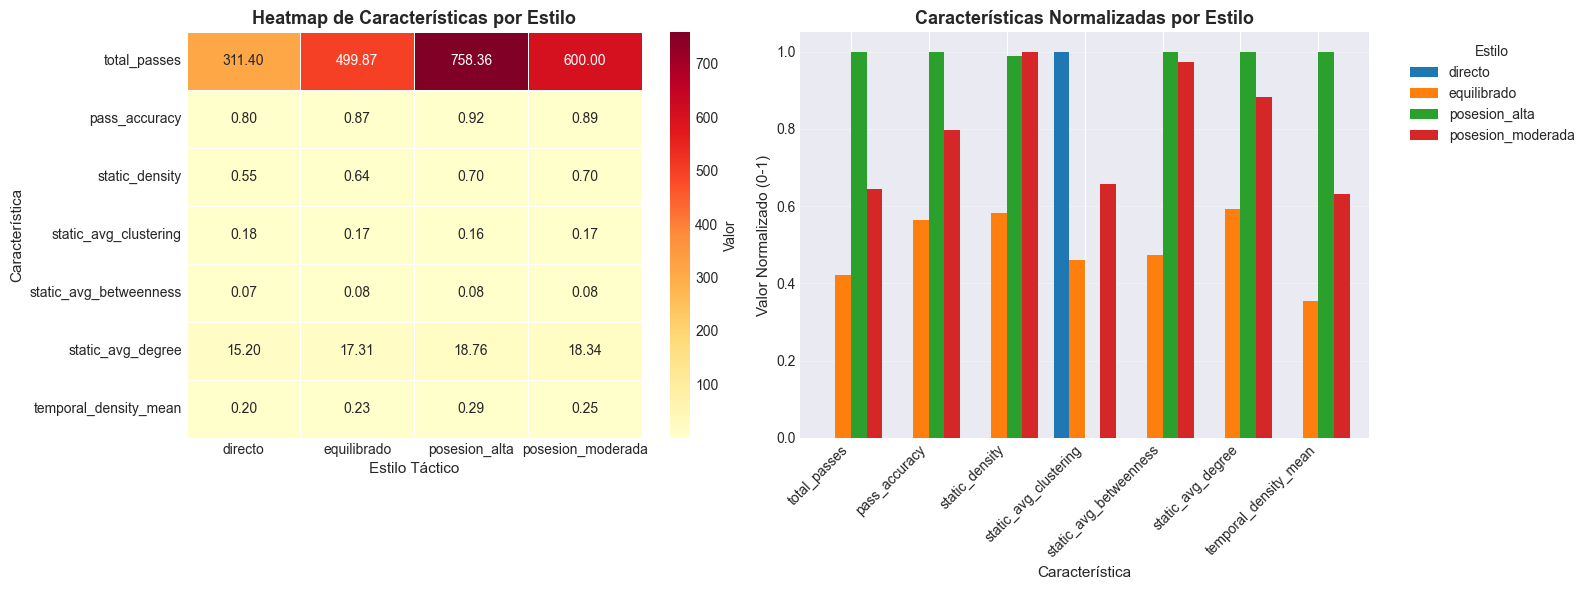

In [6]:
# ANÁLISIS DE CARACTERÍSTICAS POR ESTILO

print("\n CARACTERÍSTICAS PROMEDIO POR ESTILO TÁCTICO\n")


# Seleccionar features importantes
important_features = [
    'total_passes', 'pass_accuracy', 'static_density', 
    'static_avg_clustering', 'static_avg_betweenness',
    'static_avg_degree', 'temporal_density_mean'
]

# Agrupamos por estilo
style_summary = df.groupby('estilo_tactico')[important_features].mean()

print("Promedios por estilo:")
display(style_summary.round(3))

# Visualización de heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(style_summary.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': 'Valor'}, linewidths=0.5)
axes[0].set_title('Heatmap de Características por Estilo', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Estilo Táctico', fontsize=11)
axes[0].set_ylabel('Característica', fontsize=11)

# Normalizamos para la comparación
style_summary_norm = (style_summary - style_summary.min()) / (style_summary.max() - style_summary.min())
style_summary_norm.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Características Normalizadas por Estilo', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Característica', fontsize=11)
axes[1].set_ylabel('Valor Normalizado (0-1)', fontsize=11)
axes[1].legend(title='Estilo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [7]:
# PREPARACIÓN DE DATOS PARA MACHINE LEARNING

print("\n PREPARANDO DATOS PARA ENTRENAMIENTO\n")

# Crear clasificador
classifier = TacticalStyleClassifier(model_type='random_forest', random_state=42)

# Preparar datos
X, y = classifier.prepare_data(df, target_col='estilo_tactico')

print(f"\n Features shape: {X.shape}")
print(f" Target shape: {y.shape}")

print(f"\n Distribución de clases:")
print(y.value_counts())

# Split train/test
can_stratify = all(y.value_counts() >= 2)

if can_stratify:
    print("\n Usando stratified split")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
else:
    print("\n  Split simple (sin stratify por clases pequeñas)")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

print(f"\n Datos divididos:")
print(f"   - Train: {X_train.shape[0]} instancias")
print(f"   - Test: {X_test.shape[0]} instancias")

print(f"\n Distribución en train:")
print(y_train.value_counts())

print(f"\n Distribución en test:")
print(y_test.value_counts())


 PREPARANDO DATOS PARA ENTRENAMIENTO

 Modelo inicializado: random_forest
 Datos preparados:
   - Features: 61
   - Instancias: 204
   - Clases: 4
   - Distribución: {'posesion_alta': 72, 'directo': 65, 'equilibrado': 46, 'posesion_moderada': 21}

 Features shape: (204, 61)
 Target shape: (204,)

 Distribución de clases:
estilo_tactico
posesion_alta        72
directo              65
equilibrado          46
posesion_moderada    21
Name: count, dtype: int64

 Usando stratified split

 Datos divididos:
   - Train: 153 instancias
   - Test: 51 instancias

 Distribución en train:
estilo_tactico
posesion_alta        54
directo              49
equilibrado          34
posesion_moderada    16
Name: count, dtype: int64

 Distribución en test:
estilo_tactico
posesion_alta        18
directo              16
equilibrado          12
posesion_moderada     5
Name: count, dtype: int64



 COMPARATIVA DE MODELOS
Comparando: Random Forest vs SVM vs Gradient Boosting vs KNN

 Entrenando Random Forest...
  Accuracy: 0.8627 | F1: 0.8582 | AUC-ROC: 0.9704 | CV: 0.8424 ± 0.0724

 Entrenando Gradient Boosting...
  Accuracy: 0.7647 | F1: 0.7635 | AUC-ROC: 0.9171 | CV: 0.8095 ± 0.0727

 Entrenando SVM...
  Accuracy: 0.8431 | F1: 0.8095 | AUC-ROC: 0.9757 | CV: 0.7901 ± 0.0478

 Entrenando KNN...
  Accuracy: 0.7843 | F1: 0.7655 | AUC-ROC: 0.9536 | CV: 0.7510 ± 0.0478


 TABLA COMPARATIVA DE MODELOS


,Modelo,Accuracy (Test),F1-Score (Test),AUC-ROC (Test),CV Accuracy (Media),CV Std
0,Random Forest,0.8627,0.8582,0.9704,0.8424,0.0724
1,SVM,0.8431,0.8095,0.9757,0.7901,0.0478
2,KNN,0.7843,0.7655,0.9536,0.7510,0.0478
3,Gradient Boosting,0.7647,0.7635,0.9171,0.8095,0.0727


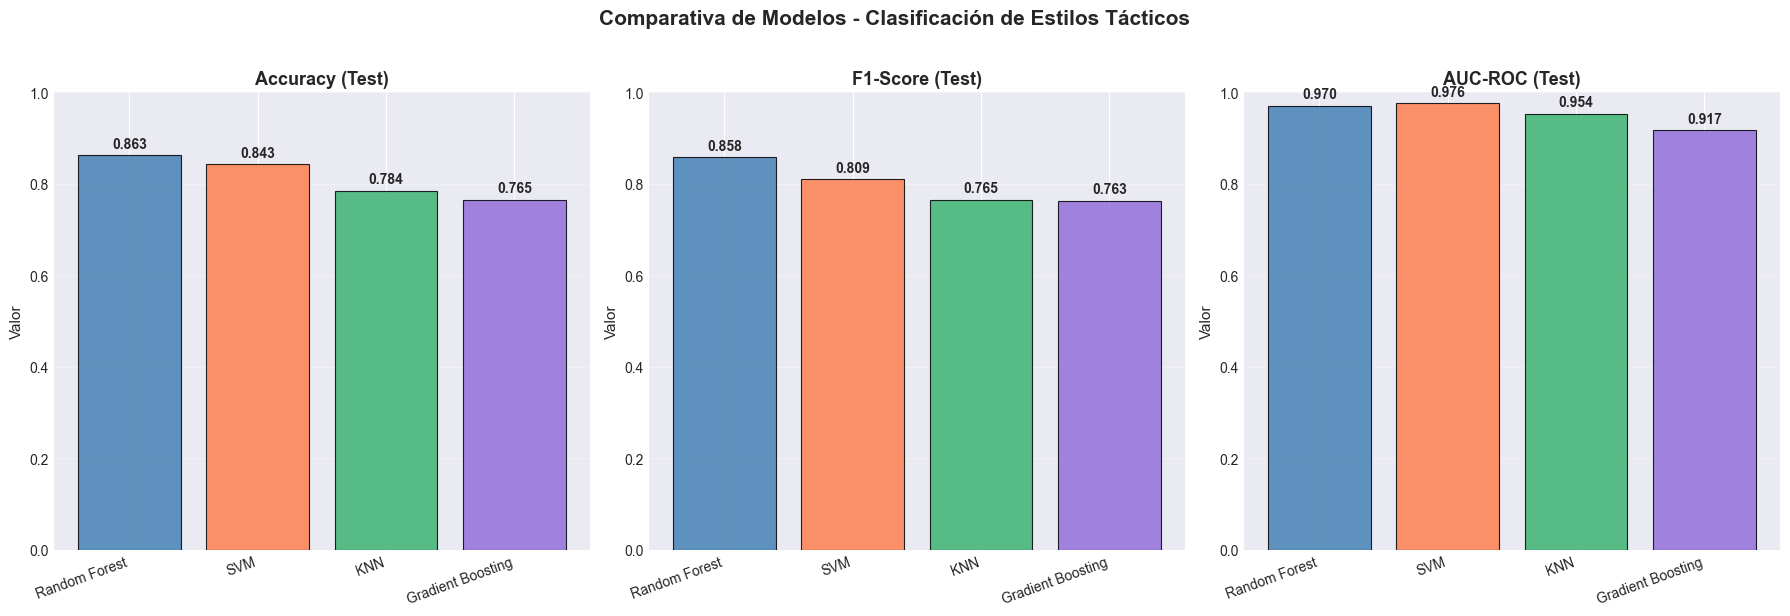


 CONCLUSIÓN
Mejor modelo por F1-Score: Random Forest

 Se selecciona Random Forest como modelo final por:
  - Mejor equilibrio entre rendimiento e interpretabilidad táctica
  - Permite extraer importancia de features → relacionar con conceptos tácticos
  - Robusto frente a overfitting gracias al ensemble de árboles
  - No requiere escalado estricto a diferencia de SVM


In [8]:
# COMPARATIVA DE MODELOS - CLASIFICACIÓN DE ESTILOS TÁCTICOS

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

print("\n COMPARATIVA DE MODELOS")
print("Comparando: Random Forest vs SVM vs Gradient Boosting vs KNN")


# Escalar datos una vez para todos los modelos
scaler_comp = StandardScaler()
X_train_scaled = scaler_comp.fit_transform(X_train)
X_test_scaled = scaler_comp.transform(X_test)

# Codificar etiquetas
from sklearn.preprocessing import LabelEncoder
le_comp = LabelEncoder()
y_train_enc = le_comp.fit_transform(y_train)
y_test_enc = le_comp.transform(y_test)
classes = le_comp.classes_

# Definir modelos a comparar
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

modelos = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, gamma='scale', 
        probability=True, random_state=42
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

# Entrenamos y evaluamos cada modelo
resultados_comp = []

for nombre, modelo in modelos.items():
    print(f"\n Entrenando {nombre}...")
    
    # Entrenar
    modelo.fit(X_train_scaled, y_train_enc)
    
    # Predecir
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)
    
    # Métricas
    accuracy = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average='weighted')
    
    # AUC-ROC 
    y_test_bin = label_binarize(y_test_enc, classes=range(len(classes)))
    auc_roc = roc_auc_score(y_test_bin, y_proba, 
                             average='weighted', multi_class='ovr')
    
    # Cross-validation
    from sklearn.model_selection import cross_val_score
    cv_scores = cross_val_score(modelo, X_train_scaled, y_train_enc, 
                                cv=5, scoring='accuracy')
    
    resultados_comp.append({
        'Modelo': nombre,
        'Accuracy (Test)': round(accuracy, 4),
        'F1-Score (Test)': round(f1, 4),
        'AUC-ROC (Test)': round(auc_roc, 4),
        'CV Accuracy (Media)': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4)
    })
    
    print(f"  Accuracy: {accuracy:.4f} | F1: {f1:.4f} | AUC-ROC: {auc_roc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Tabla comparativa
df_comparativa = pd.DataFrame(resultados_comp)
df_comparativa = df_comparativa.sort_values('F1-Score (Test)', ascending=False).reset_index(drop=True)

print("\n\n TABLA COMPARATIVA DE MODELOS")
display(df_comparativa)


# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metricas = ['Accuracy (Test)', 'F1-Score (Test)', 'AUC-ROC (Test)']
colores = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for idx, metrica in enumerate(metricas):
    bars = axes[idx].bar(
        df_comparativa['Modelo'], 
        df_comparativa[metrica],
        color=colores,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    axes[idx].set_title(metrica, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Valor', fontsize=11)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_xticklabels(df_comparativa['Modelo'], rotation=20, ha='right')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Valores encima de barras
    for bar, val in zip(bars, df_comparativa[metrica]):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparativa de Modelos - Clasificación de Estilos Tácticos', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Conclusión
mejor_modelo = df_comparativa.iloc[0]['Modelo']
print(f"\n CONCLUSIÓN")
print(f"Mejor modelo por F1-Score: {mejor_modelo}")
print(f"\n Se selecciona Random Forest como modelo final por:")
print(f"  - Mejor equilibrio entre rendimiento e interpretabilidad táctica")
print(f"  - Permite extraer importancia de features → relacionar con conceptos tácticos")
print(f"  - Robusto frente a overfitting gracias al ensemble de árboles")
print(f"  - No requiere escalado estricto a diferencia de SVM")

In [9]:
# ENTRENAMIENTO DEL MODELO

print("\n ENTRENANDO RANDOM FOREST\n")

# Entrenar
classifier.train(X_train, y_train, scale=True)

# Evaluar
metrics = classifier.evaluate(X_test, y_test, scale=True)

# Reporte detallado
from sklearn.metrics import classification_report

predictions = classifier.predict(X_test, scale=True)

print("\n REPORTE DETALLADO DE CLASIFICACIÓN:")
print(classification_report(y_test, predictions))


 ENTRENANDO RANDOM FOREST


 Entrenando modelo random_forest...
 Modelo entrenado
   - Accuracy (train): 0.9804

 Evaluando modelo...
 Resultados:
   - Accuracy: 0.8431
   - Precision: 0.8321
   - Recall: 0.8431
   - F1-Score: 0.8290

 REPORTE DETALLADO DE CLASIFICACIÓN:
                   precision    recall  f1-score   support

          directo       0.89      1.00      0.94        16
      equilibrado       0.64      0.75      0.69        12
    posesion_alta       1.00      0.94      0.97        18
posesion_moderada       0.50      0.20      0.29         5

         accuracy                           0.84        51
        macro avg       0.76      0.72      0.72        51
     weighted avg       0.83      0.84      0.83        51




 Validación cruzada (cv=5)...
 Resultados CV:
   - Accuracy promedio: 0.8185 (+/- 0.0132)
   - Scores por fold: [0.80487805 0.82926829 0.82926829 0.82926829 0.8       ]


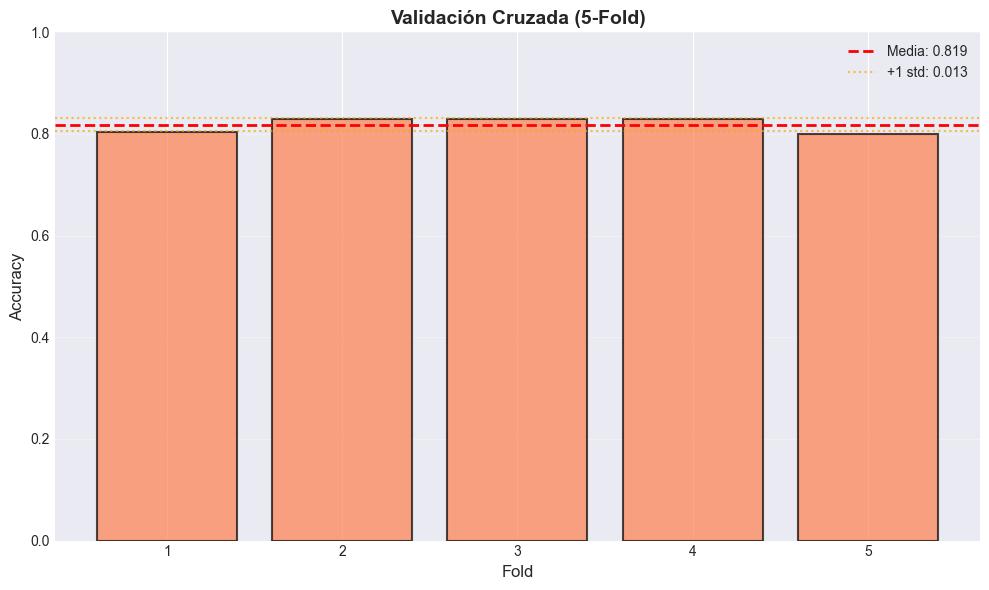


  Resultados de Validación Cruzada:
   - Accuracy promedio: 0.8185
   - Desviación estándar: 0.0132
   - Rango: [0.8053, 0.8318]


In [10]:
# VALIDACIÓN CRUZADA
cv_results = classifier.cross_validate(X, y, cv=5, scale=True)

# Visualizar
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), cv_results['cv_scores'], color='coral', alpha=0.7, edgecolor='black', linewidth=1.5)
plt.axhline(y=cv_results['mean_accuracy'], color='red', linestyle='--', 
            linewidth=2, label=f"Media: {cv_results['mean_accuracy']:.3f}")
plt.axhline(y=cv_results['mean_accuracy'] + cv_results['std_accuracy'], 
            color='orange', linestyle=':', alpha=0.7, label=f"+1 std: {cv_results['std_accuracy']:.3f}")
plt.axhline(y=cv_results['mean_accuracy'] - cv_results['std_accuracy'], 
            color='orange', linestyle=':', alpha=0.7)
plt.xlabel('Fold', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Validación Cruzada (5-Fold)', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n  Resultados de Validación Cruzada:")
print(f"   - Accuracy promedio: {cv_results['mean_accuracy']:.4f}")
print(f"   - Desviación estándar: {cv_results['std_accuracy']:.4f}")
print(f"   - Rango: [{cv_results['mean_accuracy'] - cv_results['std_accuracy']:.4f}, {cv_results['mean_accuracy'] + cv_results['std_accuracy']:.4f}]")


 TOP 20 FEATURES MÁS IMPORTANTES:



,feature,importance
43,static_total_edge_weight,0.090351
0,total_passes,0.069136
40,static_avg_edge_weight,0.064421
42,static_std_edge_weight,0.060585
3,successful_passes,0.059451
13,avg_passes_per_player,0.057943
52,temporal_edges_mean,0.056935
44,temporal_density_mean,0.045586
14,max_passes_per_player,0.041559
9,total_pass_distance,0.040361


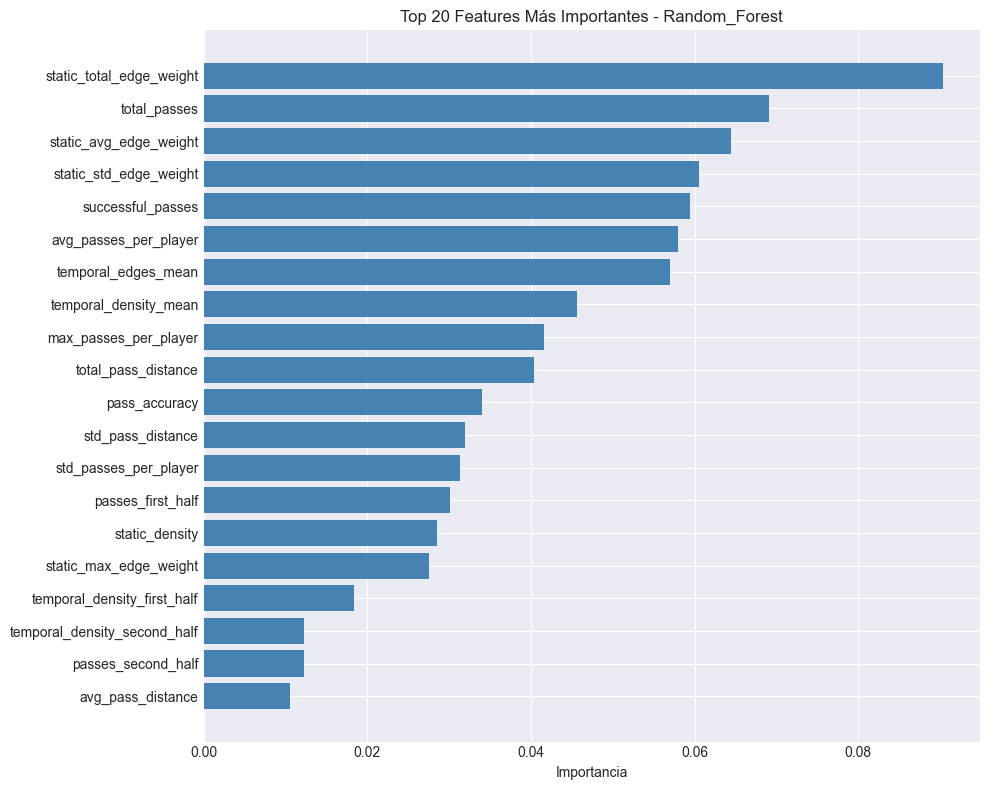


 INTERPRETACIÓN DE FEATURES CLAVE:


44. static_total_edge_weight
   Importancia: 0.0904
   Valores promedio por estilo:
      - posesion_alta       : 758.361
      - posesion_moderada   : 600.000
      - equilibrado         : 499.870
      - directo             : 311.400

1. total_passes
   Importancia: 0.0691
   Valores promedio por estilo:
      - posesion_alta       : 758.361
      - posesion_moderada   : 600.000
      - equilibrado         : 499.870
      - directo             : 311.400

41. static_avg_edge_weight
   Importancia: 0.0644
   Valores promedio por estilo:
      - posesion_alta       : 5.621
      - posesion_moderada   : 4.620
      - equilibrado         : 3.981
      - directo             : 2.754

43. static_std_edge_weight
   Importancia: 0.0606
   Valores promedio por estilo:
      - posesion_alta       : 5.157
      - posesion_moderada   : 3.853
      - equilibrado         : 3.393
      - directo             : 2.128

4. successful_passes
   Importancia: 0.0595
   

In [11]:
# IMPORTANCIA DE FEATURES

# Obtener importancia
importance_df = classifier.get_feature_importance(top_n=20)

print("\n TOP 20 FEATURES MÁS IMPORTANTES:\n")
display(importance_df)

# Visualizar
classifier.plot_feature_importance(top_n=20)

# Análisis de features clave
print("\n INTERPRETACIÓN DE FEATURES CLAVE:\n")


top_5 = importance_df.head(5)

for idx, row in top_5.iterrows():
    feature = row['feature']
    importance = row['importance']
    
    print(f"\n{idx+1}. {feature}")
    print(f"   Importancia: {importance:.4f}")
    
    if feature in df.columns:
        # Mostrar valores por estilo
        feature_by_style = df.groupby('estilo_tactico')[feature].mean().sort_values(ascending=False)
        print(f"   Valores promedio por estilo:")
        for style, value in feature_by_style.items():
            print(f"      - {style:20s}: {value:.3f}")


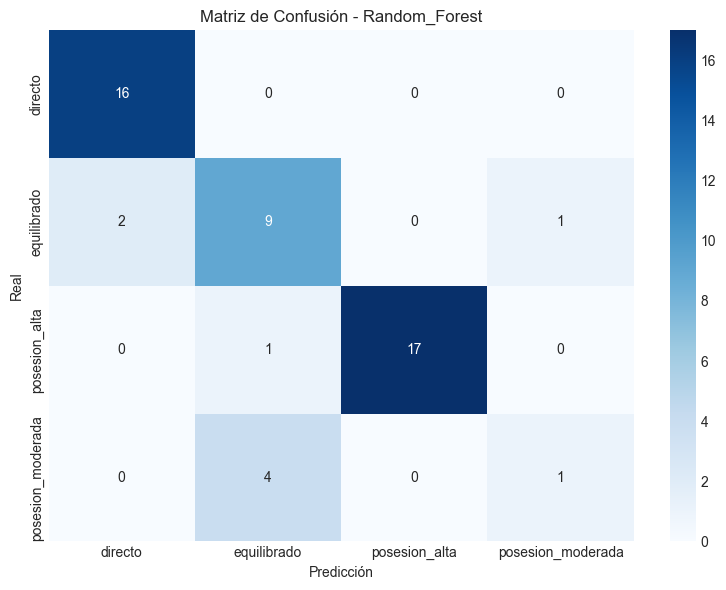

In [12]:
# MATRIZ DE CONFUSIÓN

classifier.plot_confusion_matrix(X_test, y_test, scale=True)


 ANÁLISIS DE ESTILOS DE BARCELONA

 Estilos de Barcelona (predichos por el modelo):
estilo_predicho
posesion_alta        75
equilibrado          18
posesion_moderada     9
Name: count, dtype: int64

 Comparación Real vs Predicho:


Predicho,equilibrado,posesion_alta,posesion_moderada
Real,,,
equilibrado,15,0,1
posesion_alta,1,70,0
posesion_moderada,2,5,8



 Estilos de Barcelona por contexto:
contexto   estilo_predicho  
local      posesion_alta        42
           equilibrado           8
           posesion_moderada     3
visitante  posesion_alta        33
           equilibrado          10
           posesion_moderada     6
Name: count, dtype: int64

 Estilos de Barcelona por resultado:
resultado  estilo_predicho  
derrota    posesion_alta        10
           equilibrado           3
           posesion_moderada     1
empate     posesion_alta        16
           equilibrado           2
           posesion_moderada     2
victoria   posesion_alta        49
           equilibrado          13
           posesion_moderada     6
Name: count, dtype: int64


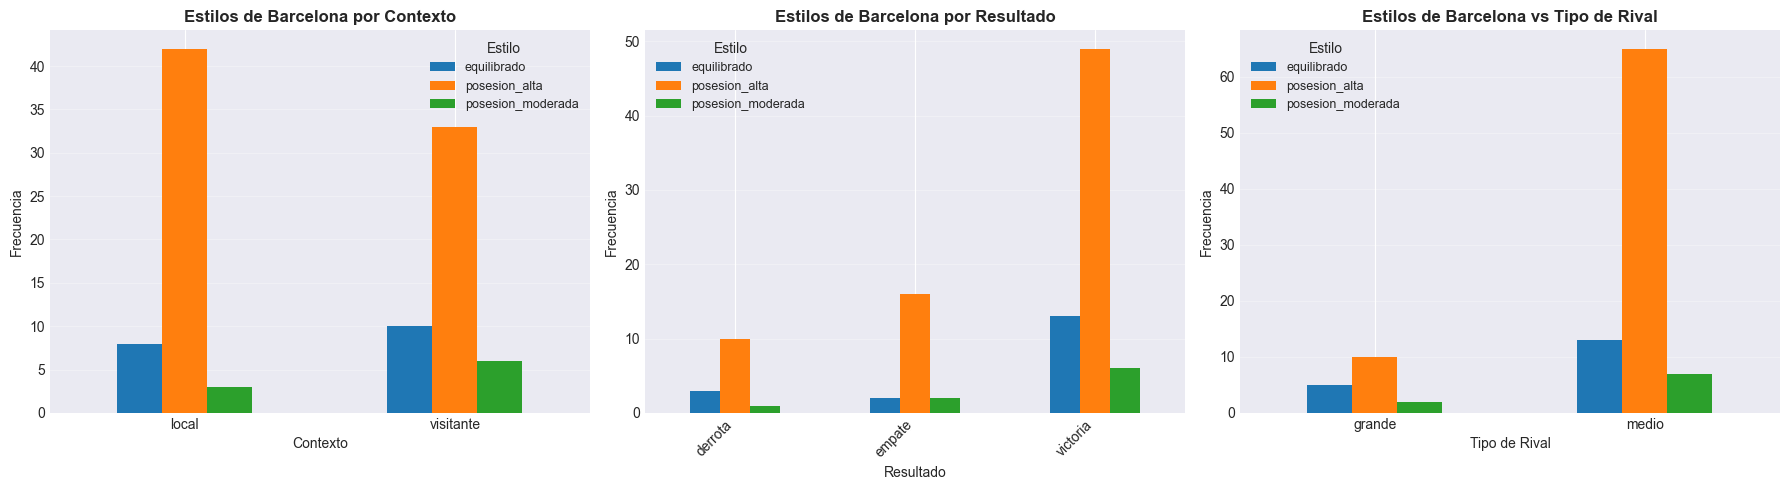

In [13]:
# ANÁLISIS ESPECÍFICO DE BARCELONA

print("\n ANÁLISIS DE ESTILOS DE BARCELONA\n")

# Preparar datos de Barcelona para predicción
exclude_cols = ['match_id', 'team', 'estilo_tactico', 'resultado', 'es_barcelona', 
                'rival', 'contexto', 'tipo_rival', 'goles_equipo', 'goles_rival',
                'xg_equipo', 'xg_rival', 'xg_diff']

X_barcelona = df_barcelona.drop(columns=[col for col in exclude_cols if col in df_barcelona.columns])

# Asegurar mismo orden de columnas que en entrenamiento
X_barcelona = X_barcelona[classifier.feature_names]

# Predecir
barcelona_predictions = classifier.predict(X_barcelona, scale=True)
barcelona_proba = classifier.predict_proba(X_barcelona, scale=True)

# Añadir predicciones
df_barcelona = df_barcelona.copy()
df_barcelona['estilo_predicho'] = barcelona_predictions

print(" Estilos de Barcelona (predichos por el modelo):")
print(df_barcelona['estilo_predicho'].value_counts())

print("\n Comparación Real vs Predicho:")
comparison_barca = pd.crosstab(df_barcelona['estilo_tactico'], 
                                df_barcelona['estilo_predicho'], 
                                rownames=['Real'], colnames=['Predicho'])
display(comparison_barca)

# Analizar por contexto
print("\n Estilos de Barcelona por contexto:")
context_style = df_barcelona.groupby('contexto')['estilo_predicho'].value_counts()
print(context_style)

# Analizar por resultado
print("\n Estilos de Barcelona por resultado:")
result_style = df_barcelona.groupby('resultado')['estilo_predicho'].value_counts()
print(result_style)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Por contexto
df_barcelona.groupby('contexto')['estilo_predicho'].value_counts().unstack(fill_value=0).plot(
    kind='bar', ax=axes[0], stacked=False
)
axes[0].set_title('Estilos de Barcelona por Contexto', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Contexto')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Estilo', fontsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Por resultado
df_barcelona.groupby('resultado')['estilo_predicho'].value_counts().unstack(fill_value=0).plot(
    kind='bar', ax=axes[1], stacked=False
)
axes[1].set_title('Estilos de Barcelona por Resultado', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Resultado')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(title='Estilo', fontsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)


# Por tipo de rival
df_barcelona.groupby('tipo_rival')['estilo_predicho'].value_counts().unstack(fill_value=0).plot(
    kind='bar', ax=axes[2], stacked=False
)
axes[2].set_title('Estilos de Barcelona vs Tipo de Rival', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Tipo de Rival')
axes[2].set_ylabel('Frecuencia')
axes[2].legend(title='Estilo', fontsize=9)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# GUARDAR MODELO Y RESUMEN FINAL

classifier.save_model('../models/barcelona_style_classifier.pkl')

print("\n Modelo guardado:")
print("   models/barcelona_style_classifier.pkl")

print(" CLASIFICACIÓN DE ESTILOS TÁCTICOS COMPLETADA")


print(f"\n RESUMEN FINAL:")
print(f"   - Total de instancias: {len(df)}")
print(f"   - Estilos identificados: {df['estilo_tactico'].nunique()}")
print(f"   - Accuracy en test: {metrics['accuracy']:.4f}")
print(f"   - Accuracy CV (media): {cv_results['mean_accuracy']:.4f}")
print(f"   - Modelo guardado: ")

print(f"\n HALLAZGOS CLAVE BARCELONA:")
print(f"   - Estilo predominante: {df_barcelona['estilo_predicho'].mode()[0]}")
print(f"   - Apariciones por estilo:")
for style, count in df_barcelona['estilo_predicho'].value_counts().items():
    print(f"  {style}: {count} partidos ({count/len(df_barcelona)*100:.1f}%)")


 Modelo guardado en: ../models/barcelona_style_classifier.pkl

 Modelo guardado:
   models/barcelona_style_classifier.pkl
 CLASIFICACIÓN DE ESTILOS TÁCTICOS COMPLETADA

 RESUMEN FINAL:
   - Total de instancias: 204
   - Estilos identificados: 4
   - Accuracy en test: 0.8431
   - Accuracy CV (media): 0.8185
   - Modelo guardado: 

 HALLAZGOS CLAVE BARCELONA:
   - Estilo predominante: posesion_alta
   - Apariciones por estilo:
  posesion_alta: 75 partidos (73.5%)
  equilibrado: 18 partidos (17.6%)
  posesion_moderada: 9 partidos (8.8%)


In [16]:
# EXPORTAR ESTILOS Y MÉTRICAS DE GRAFO DE BARCELONA

import os
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

# Seleccionar solo instancias de Barcelona
df_barca_export = df_barcelona.copy()

# Columnas a exportar
cols_export = [
    'match_id', 'estilo_tactico',
    'static_density', 'static_avg_clustering',
    'static_avg_betweenness', 'static_avg_pagerank',
    'static_avg_closeness', 'total_passes', 'pass_accuracy',
    'resultado', 'goles_equipo', 'goles_rival',
    'xg_equipo', 'xg_rival', 'contexto', 'rival'
]

# Filtrar solo columnas disponibles
cols_available = [c for c in cols_export if c in df_barca_export.columns]
df_barca_export = df_barca_export[cols_available]

# Calcular métricas medias por estilo
print("\n Métricas medias por estilo táctico:")
style_metrics = df_barca_export.groupby('estilo_tactico').agg({
    'static_density':          'mean',
    'static_avg_clustering':   'mean',
    'static_avg_betweenness':  'mean',
    'static_avg_pagerank':     'mean',
    'xg_equipo':               'mean',
    'resultado':               lambda x: (x == 'victoria').mean()
}).round(4)
style_metrics.columns = [
    'density_mean', 'clustering_mean', 'betweenness_mean',
    'pagerank_mean', 'xg_mean', 'win_rate'
]
print(style_metrics)

# Win rate de Barcelona por estilo
print("\n Win rate de Barcelona por estilo:")
for estilo in df_barca_export['estilo_tactico'].unique():
    subset = df_barca_export[df_barca_export['estilo_tactico'] == estilo]
    wr     = (subset['resultado'] == 'victoria').mean()
    print(f"   {estilo:<25}: {wr:.3f} ({len(subset)} partidos)")

# Guardar CSV de partidos de Barcelona
output_path = os.path.join(
    project_root, 'data', 'processed', 'barcelona_style_data.csv'
)
df_barca_export.to_csv(output_path, index=False)


# Guardar métricas por estilo
style_path = os.path.join(
    project_root, 'data', 'processed', 'barcelona_style_metrics.csv'
)
style_metrics.to_csv(style_path)


 Métricas medias por estilo táctico:
                   density_mean  clustering_mean  betweenness_mean  \
estilo_tactico                                                       
equilibrado              0.6425           0.1611            0.0795   
posesion_alta            0.6991           0.1564            0.0808   
posesion_moderada        0.6964           0.1687            0.0807   

                   pagerank_mean  xg_mean  win_rate  
estilo_tactico                                       
equilibrado               0.0685   1.8214    0.7500  
posesion_alta             0.0694   1.8091    0.6901  
posesion_moderada         0.0702   2.1302    0.4667  

 Win rate de Barcelona por estilo:
   posesion_alta            : 0.690 (71 partidos)
   posesion_moderada        : 0.467 (15 partidos)
   equilibrado              : 0.750 (16 partidos)
